In [6]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("Housing.csv")

In [8]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


In [9]:
print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (545, 10)


In [10]:
# Task 1: Data Exploration

In [11]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes
5,10850000,7500,3,3,1,yes,no,yes,no,yes
6,10150000,8580,4,3,4,yes,no,no,no,yes
7,10150000,16200,5,3,2,yes,no,no,no,no
8,9870000,8100,4,1,2,yes,yes,yes,no,yes
9,9800000,5750,3,2,4,yes,yes,no,no,yes


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 545
Number of columns: 10


In [13]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning'],
      dtype='object')


In [14]:
target = 'price'
features = df.columns.drop('price')

print("Target Variable:", target)
print("\nFeatures:")
print(features)

Target Variable: price

Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning'],
      dtype='object')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


In [16]:
df.isnull().sum()

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
dtype: int64

In [17]:
df.describe()

,price,area,bedrooms,bathrooms,stories
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000


In [18]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [19]:
df = df.drop_duplicates()

In [20]:
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (545, 10)


In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes
0,13300000,7420,4,2,3,True,False,False,False,True
1,12250000,8960,4,4,4,True,False,False,False,True
2,12250000,9960,3,2,2,True,False,True,False,False
3,12215000,7500,4,2,2,True,False,True,False,True
4,11410000,7420,4,1,2,True,True,True,False,True


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   price                545 non-null    int64
 1   area                 545 non-null    int64
 2   bedrooms             545 non-null    int64
 3   bathrooms            545 non-null    int64
 4   stories              545 non-null    int64
 5   mainroad_yes         545 non-null    bool 
 6   guestroom_yes        545 non-null    bool 
 7   basement_yes         545 non-null    bool 
 8   hotwaterheating_yes  545 non-null    bool 
 9   airconditioning_yes  545 non-null    bool 
dtypes: bool(5), int64(5)
memory usage: 24.1 KB


In [24]:
X = df.drop("price", axis=1)
y = df["price"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (545, 9)
Shape of y: (545,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (436, 9)
Testing set shape: (109, 9)


In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 9)
X_test : (109, 9)
y_train: (436,)
y_test : (109,)


In [27]:
# Create the Linear Regression model
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [28]:
lr_pred = lr.predict(X_test)

print("First 5 predictions:")
print(lr_pred[:5])

First 5 predictions:
[5416967.08149048 6818564.06211807 3210479.195361   4875625.14092177
 3307044.88314089]


In [29]:
mae = mean_absolute_error(y_test, lr_pred)

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Performance
MAE : 1029305.7135858473
RMSE: 1413204.6185031156
R² Score: 0.6048828690833077


In [30]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": lr_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.416967e+06
1,6650000,6.818564e+06
2,3710000,3.210479e+06
3,6440000,4.875625e+06
4,2800000,3.307045e+06
5,4900000,4.080092e+06
6,5250000,5.458604e+06
7,4543000,6.032291e+06
8,2450000,2.631205e+06
9,3353000,2.341428e+06


In [31]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [32]:
rf_pred = rf.predict(X_test)

print(rf_pred[:5])

[5174890.         6384990.         3393117.83333333 4287045.
 3616690.        ]


In [33]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
MAE : 1104205.6599505998
RMSE: 1496229.398176855
R² Score: 0.5570934218233545


In [34]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.029306e+06,1.413205e+06,0.604883
1,Random Forest,1.104206e+06,1.496229e+06,0.557093


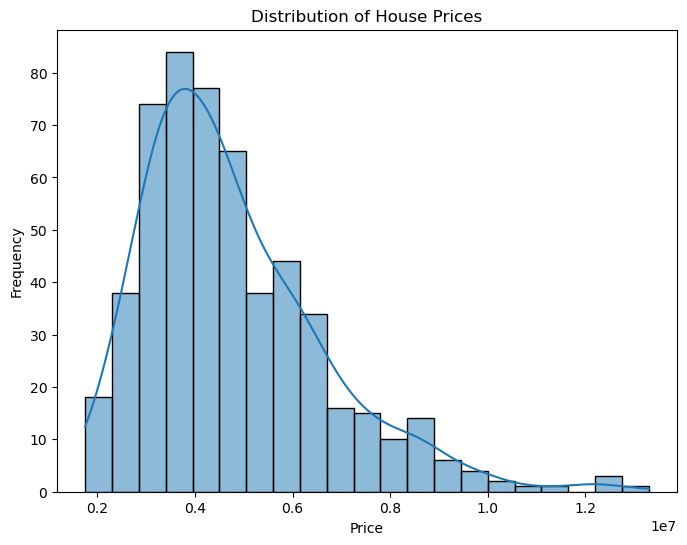

In [35]:
plt.figure(figsize=(8,6))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")
plt.show()

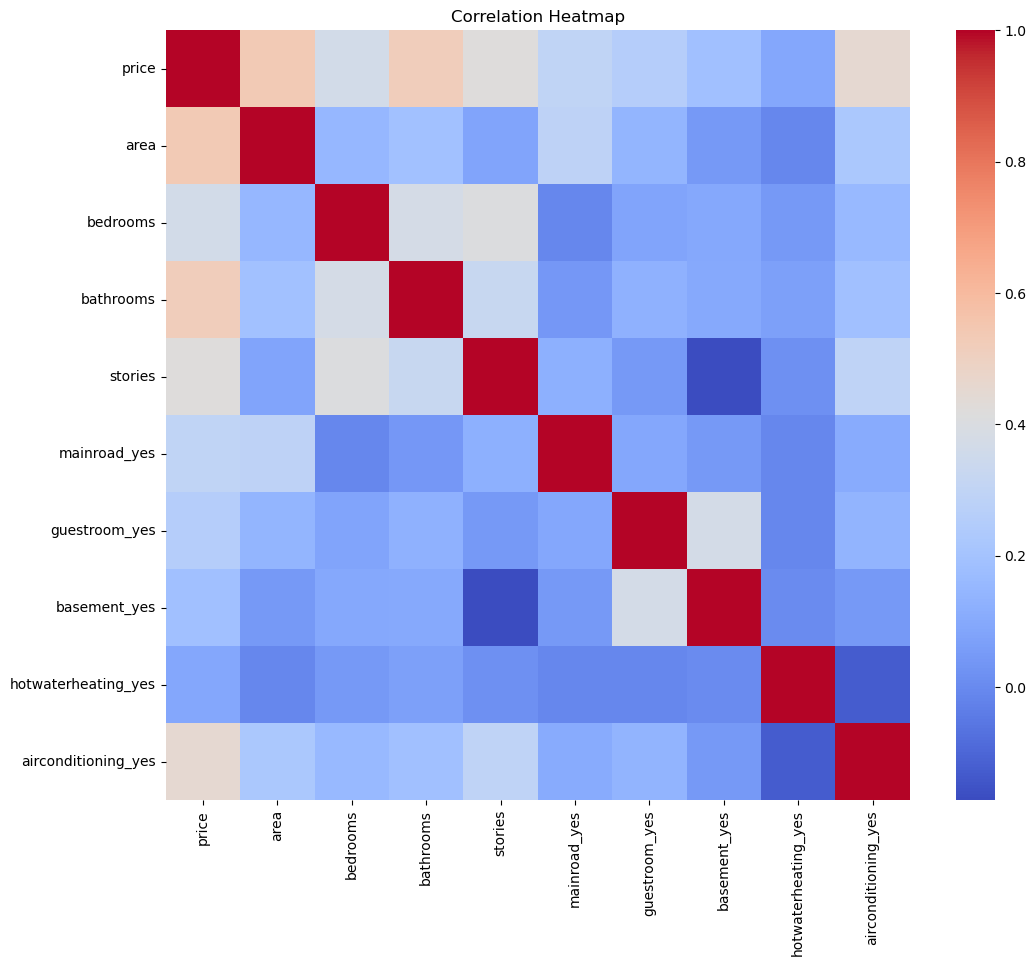

In [36]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")
plt.show()

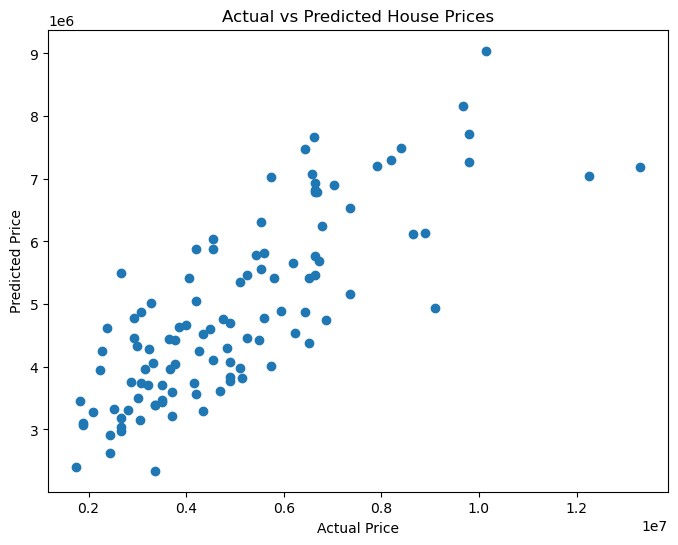

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [38]:
import os

print(os.listdir("charts"))

['.ipynb_checkpoints', 'actual_vs_predicted.png', 'correlation_heatmap.png', 'Distribution of House Prices.ipynb', 'price_distribution.png', 'Untitled.ipynb']


In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

importance['Absolute_Coefficient'] = abs(importance['Coefficient'])

importance = importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
2,bathrooms,1.119867e+06,1.119867e+06
8,airconditioning_yes,8.743500e+05,8.743500e+05
7,hotwaterheating_yes,7.307012e+05,7.307012e+05
4,mainroad_yes,6.127039e+05,6.127039e+05
6,basement_yes,5.374749e+05,5.374749e+05
3,stories,4.029370e+05,4.029370e+05
5,guestroom_yes,2.575018e+05,2.575018e+05
1,bedrooms,1.189729e+05,1.189729e+05
0,area,2.800897e+02,2.800897e+02


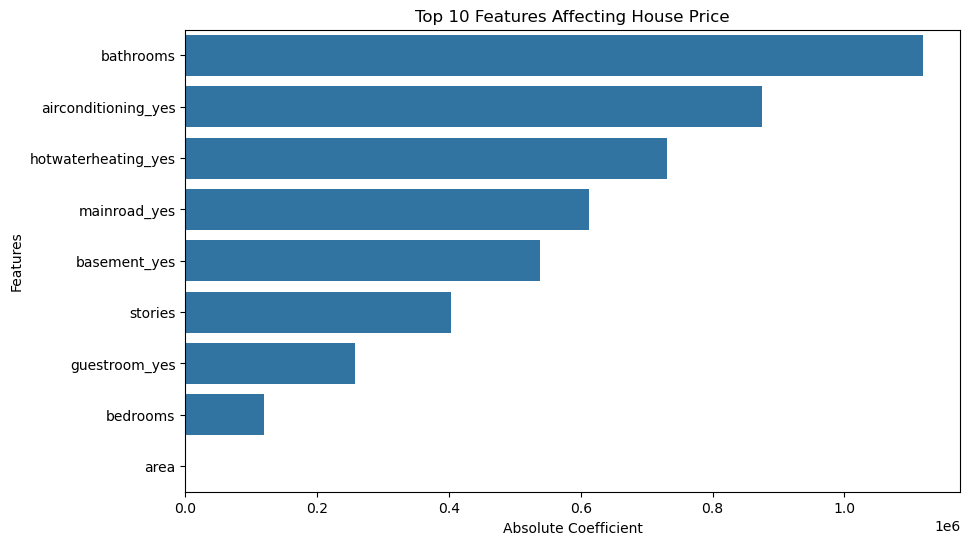

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Absolute_Coefficient',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Features Affecting House Price')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')

plt.savefig('charts/feature_importance.png')
plt.show()

In [41]:
importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
2,bathrooms,1.119867e+06,1.119867e+06
8,airconditioning_yes,8.743500e+05,8.743500e+05
7,hotwaterheating_yes,7.307012e+05,7.307012e+05
4,mainroad_yes,6.127039e+05,6.127039e+05
6,basement_yes,5.374749e+05,5.374749e+05
3,stories,4.029370e+05,4.029370e+05
5,guestroom_yes,2.575018e+05,2.575018e+05
1,bedrooms,1.189729e+05,1.189729e+05
0,area,2.800897e+02,2.800897e+02
